## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001CE3E53B880> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.374623
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.121427
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.081799
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,1.822118
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.011088


In [6]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3


In [7]:
timeline_file[['NUTS3_NAME', 'dt_placement']].value_counts().sort_values(ascending=False)

NUTS3_NAME          dt_placement
καρδιτσα, τρικαλα   2010-01-01      289
                    2010-01-17      289
                    2010-01-03      289
                    2010-01-04      289
                    2010-01-05      289
                                   ... 
μαγνησια, σποραδες  2022-12-28       96
                    2022-12-29       96
                    2022-12-30       96
                    2016-07-02       96
                    2022-12-31       96
Length: 14244, dtype: int64

In [8]:
wnv_file[['NUTS3_NAME', 'dt_placement']].value_counts().sort_values(ascending=False)

NUTS3_NAME          dt_placement
καρδιτσα, τρικαλα   2010-07         1
                    2010-08         1
                    2010-09         1
                    2010-10         1
                    2011-07         1
                    2011-08         1
                    2011-09         1
                    2011-10         1
                    2020-08         1
                    2018-07         1
                    2018-09         1
                    2018-10         1
                    2019-07         1
                    2019-08         1
                    2019-09         1
                    2019-10         1
                    2018-08         1
                    2020-07         1
                    2020-09         1
λαρισα              2018-09         1
καρδιτσα, τρικαλα   2020-10         1
                    2022-07         1
                    2022-08         1
                    2022-09         1
                    2022-10         1
λαρισα           

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.374623,NaN,NaN,NaN,NaN,NaN
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.121427,NaN,NaN,NaN,NaN,NaN
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.081799,NaN,NaN,NaN,NaN,NaN
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,1.822118,NaN,NaN,NaN,NaN,NaN
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.011088,NaN,NaN,NaN,NaN,NaN


In [11]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3


### Calculate accumulated rainfall ###

In [12]:
timeline_file.shape

(3143176, 38)

In [13]:
dataset = pd.DataFrame()
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset = dataset.append(temp_df)

dataset.reset_index(drop=True, inplace=True)

dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.941204,NaN,NaN,NaN,NaN,NaN,40.941204,40.941204,40.941204
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.769920,NaN,NaN,NaN,NaN,NaN,63.711124,63.711124,63.711124
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.007012,NaN,NaN,NaN,NaN,NaN,64.718136,64.718136,64.718136
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.641527,NaN,NaN,NaN,NaN,NaN,68.359663,68.359663,68.359663
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.385432,NaN,NaN,NaN,NaN,NaN,69.745094,69.745094,69.745094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143171,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-27,27,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14269.000000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,7.205815,1157.374877
3143172,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14269.000000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,0.000000,1157.374877
3143173,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-29,29,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14356.000000,14079.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14217.500000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,0.000000,1157.374877
3143174,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-30,30,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14239.000000,14096.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14167.500000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,0.000000,1157.374877


### Add mosqutio predictions using trained model ###

In [14]:
model = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [15]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [16]:
dataset.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [17]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [18]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [19]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [20]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

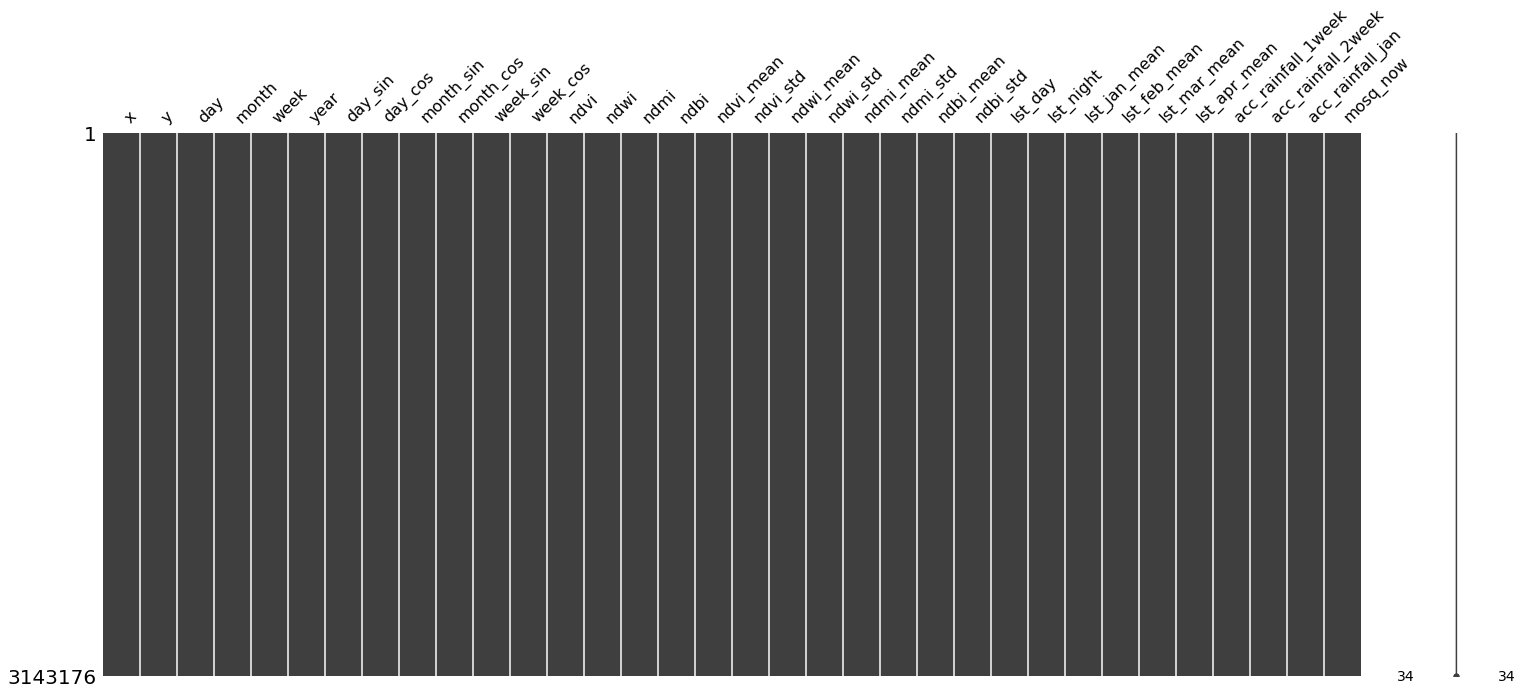

In [21]:
missingno.matrix(dataset_mamoth)

In [22]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [23]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [24]:
predictions = give_predictions(model, dataset_mamoth)

In [25]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.190130,39.661480,2010-01-01,20
1,21.190130,39.661480,2010-01-02,25
2,21.190130,39.661480,2010-01-03,25
3,21.190130,39.661480,2010-01-04,3
4,21.190130,39.661480,2010-01-05,4
...,...,...,...,...
3143171,23.299620,39.203270,2022-12-27,1
3143172,23.299620,39.203270,2022-12-28,1
3143173,23.299620,39.203270,2022-12-29,1
3143174,23.299620,39.203270,2022-12-30,1


<AxesSubplot:>

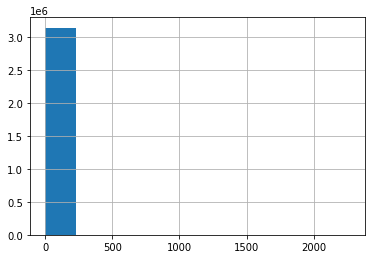

In [26]:
mosqutio_predictions.mosq_pred.hist()

In [27]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

In [28]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.941204,NaN,NaN,NaN,NaN,NaN,40.941204,40.941204,40.941204,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,20
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.769920,NaN,NaN,NaN,NaN,NaN,63.711124,63.711124,63.711124,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,25
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.007012,NaN,NaN,NaN,NaN,NaN,64.718136,64.718136,64.718136,53,0.571268,0.820763,0.500000,0.866025,-0.000000,1.000000,25
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.641527,NaN,NaN,NaN,NaN,NaN,68.359663,68.359663,68.359663,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,3
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.385432,NaN,NaN,NaN,NaN,NaN,69.745094,69.745094,69.745094,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143171,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-27,27,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14269.000000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,7.205815,1157.374877,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,1
3143172,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14269.000000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,0.000000,1157.374877,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,1
3143173,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-29,29,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14356.000000,14079.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14217.500000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,0.000000,1157.374877,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,1
3143174,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-30,30,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14239.000000,14096.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14167.500000,14071.681183,14141.750000,14054.725806,14054.7

In [29]:
grouped = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_grouped = grouped.mean()
dataset_grouped

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,2010-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14445.565789,13915.473684,14445.565789,NaN,NaN,NaN,13915.473684,NaN,NaN,NaN,39.120625,14133.222222,14133.222222,NaN,NaN,NaN,39.120625,39.120625,39.120625,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,8.463668
1,2010-01-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14453.085185,13949.820513,14453.085185,NaN,NaN,NaN,13949.820513,NaN,NaN,NaN,1.096759,14178.696581,14178.696581,NaN,NaN,NaN,1.096759,1.096759,1.096759,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,4.599278
2,2010-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14497.808511,14026.800000,14497.808511,NaN,NaN,NaN,14026.800000,NaN,NaN,NaN,0.071117,14247.500000,14247.500000,NaN,NaN,NaN,0.071117,0.071117,0.071117,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,1.000000
3,2010-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.989796,13887.059829,14301.589286,NaN,NaN,NaN,13889.260684,NaN,NaN,NaN,12.300978,14113.905941,14133.747525,NaN,NaN,NaN,51.421603,51.421603,51.421603,53.000000,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,12.207612
4,2010-01-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14423.196296,13903.841085,14438.140741,NaN,NaN,NaN,13920.750000,NaN,NaN,NaN,1.174605,14162.886454,14178.340637,NaN,NaN,NaN,2.271364,2.271364,2.271364,53.000000,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,6.671480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14239,2022-12-30,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,30.000000,12.000000,2022.000000,0.322494,0.053153,-0.252553,-0.053153,0.311524,0.056624,-0.241544,-0.056624,0.051063,0.060420,0.046550,0.060420,14214.610108,13841.870036,14140.530263,14329.032491,14362.054967,14362.054967,13677.785373,13726.381912,13683.083615,13683.083615,0.000000,14028.240072,13909.157818,14027.707202,14022.569291,14022.569291,0.056918,1.049194,1096.486878,52.000000,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,28.841155
14240,2022-12-30,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,30.000000,12.000000,2022.000000,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,14167.114583,13940.083333,14118.090952,14244.585938,14209.986223,14209.986223,13822.483871,13838.325149,13777.013441,13777.013441,0.000000,14053.598958,13970.287412,14041.455543,13993.499832,13993.499832,0.000000,0.004880,1046.578644,52.000000,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,1.010417
14241,2022-12-31,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,31.000000,12.000000,2022.000000,0.287350,0.083383,-0.219969,-0.083383,0.247052,0.093912,-0.182989,-0.093912,0.049938,0.054802,0.052715,0.054802,14161.968858,13827.096886,14051.004353,14211.365175,14195.668490,14195.668490,13694.409979,13718.294209,13676.257589,13676.257589,0.000000,13994.5328

<AxesSubplot:>

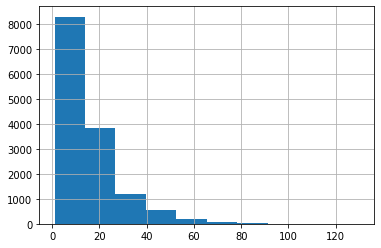

In [30]:
dataset_grouped.mosq_pred.hist()

In [31]:
dataset_grouped = convert_temperature(dataset_grouped)

<AxesSubplot:>

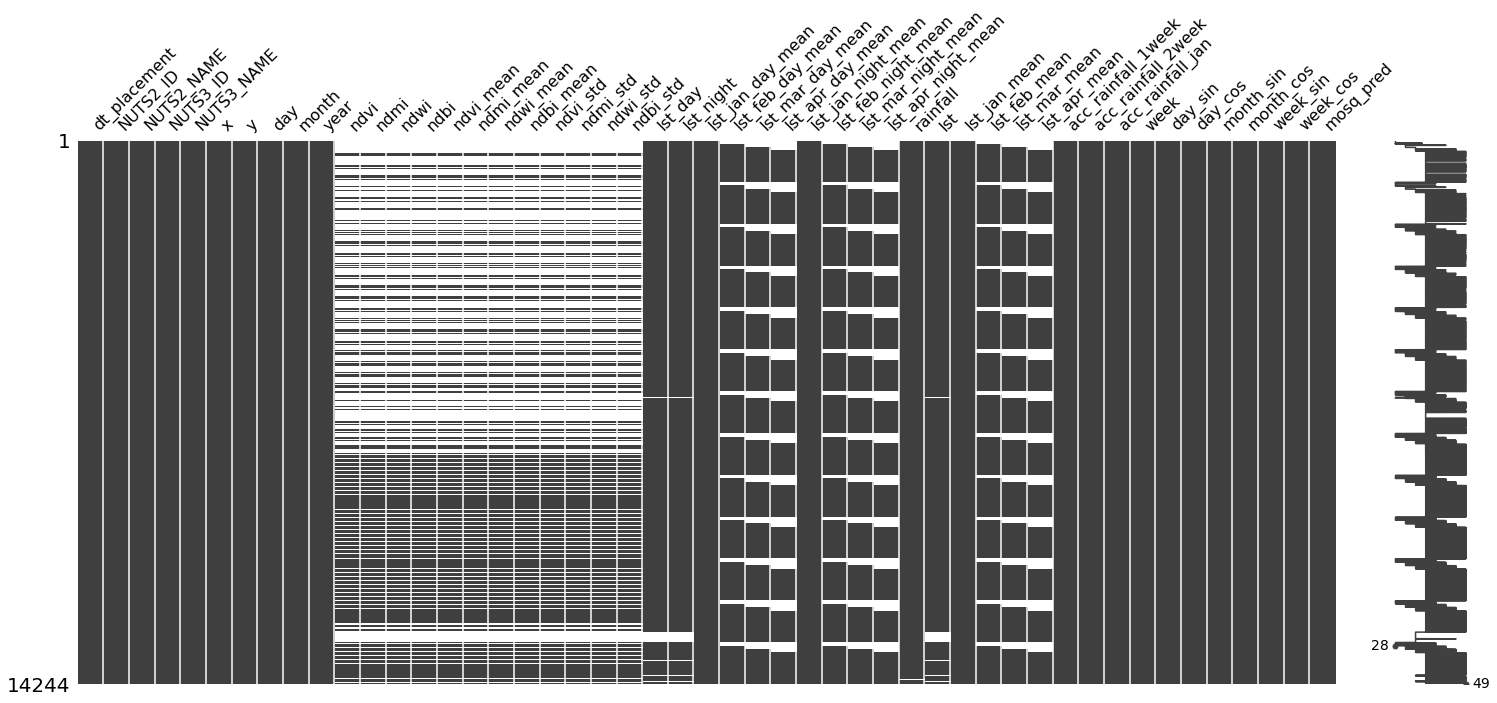

In [32]:
missingno.matrix(dataset_grouped)

### Add Bio Variables ###

In [33]:
bio_values = []

for region in dataset_grouped.NUTS3_NAME.unique():
    for year in dataset_grouped.year.unique():
        for month in dataset_grouped.month.unique():
            filtered_df = dataset_grouped.loc[(dataset_grouped['year'] == year) & (dataset_grouped['NUTS3_NAME'] == region) & (dataset_grouped['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [34]:
bio_values_df = pd.DataFrame(bio_values)

In [35]:
dataset = pd.merge(dataset_grouped, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [36]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.761316,5.159474,15.761316,NaN,NaN,NaN,5.159474,NaN,NaN,NaN,39.120625,10.460395,9.514444,NaN,NaN,NaN,39.120625,39.120625,39.120625,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,8.463668,-0.969514,15.761316,207.415431
1,2010-01-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.911704,5.846410,15.911704,NaN,NaN,NaN,5.846410,NaN,NaN,NaN,1.096759,10.879057,10.423932,NaN,NaN,NaN,1.096759,1.096759,1.096759,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,4.599278,-0.715704,15.911704,93.733414
2,2010-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.806170,7.386000,16.806170,NaN,NaN,NaN,7.386000,NaN,NaN,NaN,0.071117,12.096085,11.800000,NaN,NaN,NaN,0.071117,0.071117,0.071117,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,1.000000,0.040625,16.806170,150.488717
3,2010-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.949796,4.591197,12.881786,NaN,NaN,NaN,4.635214,NaN,NaN,NaN,12.300978,8.270496,9.524950,NaN,NaN,NaN,51.421603,51.421603,51.421603,53.000000,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,12.207612,-0.969514,15.761316,207.415431
4,2010-01-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.313926,4.926822,15.612815,NaN,NaN,NaN,5.265000,NaN,NaN,NaN,1.174605,10.120374,10.416813,NaN,NaN,NaN,2.271364,2.271364,2.271364,53.000000,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,6.671480,-0.715704,15.911704,93.733414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14239,2022-12-30,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,30.000000,12.000000,2022.000000,0.322494,0.053153,-0.252553,-0.053153,0.311524,0.056624,-0.241544,-0.056624,0.051063,0.060420,0.046550,0.060420,11.142202,3.687401,9.660605,13.430650,14.091099,14.091099,0.405707,1.377638,0.511672,0.511672,0.000000,7.414801,5.033156,7.404144,7.301386,7.301386,0.056918,1.049194,1096.486878,52.000000,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,28.841155,-0.000830,14.041480,17.777902
14240,2022-12-30,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,30.000000,12.000000,2022.000000,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,10.192292,5.651667,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,7.921979,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644,52.000000,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,1.010417,1.944167,13.649167,11.989727
14241,2022-12-31,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,31.000000,12.000000,2022.000000,0.287350,0.083383,-0.219969,-0.083383,0.247052,0.093912,-0.182989,-0.093912,0.049938,0.054802,0.052715,0.054802,10.089377,3.391938,7.870087,11.077304,10.763370,10.763370,0.738200,1.215884,0.375152,0.37515

<AxesSubplot:>

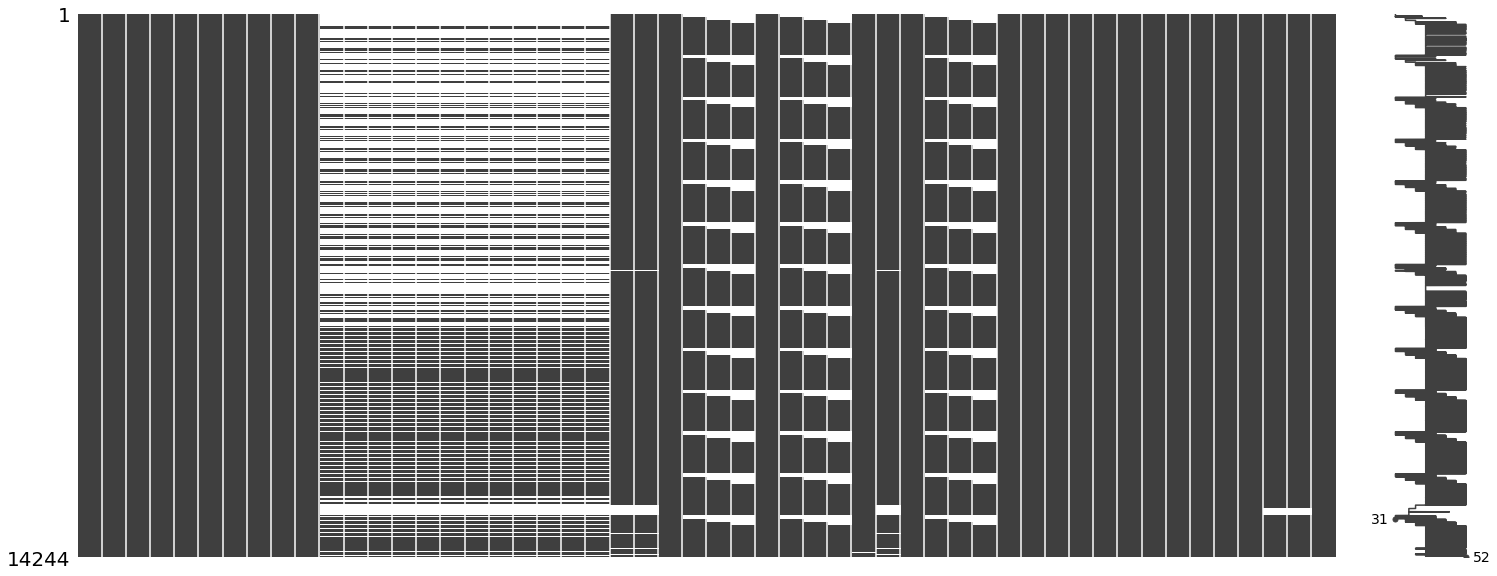

In [37]:
missingno.matrix(dataset)

In [38]:
dataset = dataset.astype({"day":"int","month":"int", "year":"int"})

In [39]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [40]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [41]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2010-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.761316,5.159474,15.761316,NaN,NaN,NaN,5.159474,NaN,NaN,NaN,39.120625,10.460395,9.514444,NaN,NaN,NaN,39.120625,39.120625,39.120625,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,8.463668,-0.969514,15.761316,207.415431,2010-01
1,2010-01-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.911704,5.846410,15.911704,NaN,NaN,NaN,5.846410,NaN,NaN,NaN,1.096759,10.879057,10.423932,NaN,NaN,NaN,1.096759,1.096759,1.096759,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,4.599278,-0.715704,15.911704,93.733414,2010-01
2,2010-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.806170,7.386000,16.806170,NaN,NaN,NaN,7.386000,NaN,NaN,NaN,0.071117,12.096085,11.800000,NaN,NaN,NaN,0.071117,0.071117,0.071117,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,1.000000,0.040625,16.806170,150.488717,2010-01
3,2010-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.949796,4.591197,12.881786,NaN,NaN,NaN,4.635214,NaN,NaN,NaN,12.300978,8.270496,9.524950,NaN,NaN,NaN,51.421603,51.421603,51.421603,53.000000,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,12.207612,-0.969514,15.761316,207.415431,2010-01
4,2010-01-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.313926,4.926822,15.612815,NaN,NaN,NaN,5.265000,NaN,NaN,NaN,1.174605,10.120374,10.416813,NaN,NaN,NaN,2.271364,2.271364,2.271364,53.000000,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,6.671480,-0.715704,15.911704,93.733414,2010-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14239,2022-12-30,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,30,12,2022,0.322494,0.053153,-0.252553,-0.053153,0.311524,0.056624,-0.241544,-0.056624,0.051063,0.060420,0.046550,0.060420,11.142202,3.687401,9.660605,13.430650,14.091099,14.091099,0.405707,1.377638,0.511672,0.511672,0.000000,7.414801,5.033156,7.404144,7.301386,7.301386,0.056918,1.049194,1096.486878,52.000000,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,28.841155,-0.000830,14.041480,17.777902,2022-12
14240,2022-12-30,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,30,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,10.192292,5.651667,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,7.921979,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644,52.000000,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,1.010417,1.944167,13.649167,11.989727,2022-12
14241,2022-12-31,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,31,12,2022,0.287350,0.083383,-0.219969,-0.083383,0.247052,0.093912,-0.182989,-0.093912,0.049938,0.054802,0.052715,0.054802,10.089377,3.391938,7.870087,11.077304,10.763370,10.763370,0.738200,1.215884,0.375152,0.375152,0.000000,6.740657,4.304143,6.163824,5.569261,5.569261,0.001830,0.011892,1027.788240,52.

In [42]:
grouped = dataset.groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)
grouped_mosq = dataset.groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)


dataset_month = grouped.mean()
dataset_month_mosq = grouped.sum()


dataset_month

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.195364,1.570202,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,3.882783,5.289864,NaN,NaN,NaN,41.517169,73.296771,117.810760,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,3.189195,-0.969514,15.761316,207.415431
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.047620,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2.219634,-0.715704,15.911704,93.733414
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.674636,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,1.000336,0.040625,16.806170,150.488717
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,14.500000,2.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.839973,1.268766,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,4.554370,3.211945,2.916904,NaN,NaN,79.217105,151.965634,370.323392,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,15.894217,-3.042901,13.286678,310.442081
4,2010-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,14.500000,2.000000,2010.000000,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,11.048597,2.689361,10.127192,9.095389,NaN,NaN,1.875504,0.537745,NaN,NaN,7.380415,6.868979,6.001348,4.861217,NaN,NaN,51.045338,97.899665,193.962831,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,10.193399,-2.894380,15.076065,206.651624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,2022-11,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,15.500000,11.000000,2022.000000,0.268091,-0.017647,-0.237168,0.017647,0.256220,-0.012099,-0.223224,0.012099,0.047753,0.055676,0.044192,0.055676,18.071148,7.933730,9.660605,13.430650,14.091099,14.091099,0.405707,1.377638,0.511672,0.511672,1.249923,13.002439,5.033156,7.404144,7.301386,7.301386,6.858943,12.685927,1062.720886,45.800000,-0.000000,-0.033333,-0.500000,0.866025,-0.745078,0.649776,36.248496,2.770072,26.371877,33.747927
464,2022-11,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,15.500000,11.000000,2022.000000,0.360639,0.137056,-0.286371,-0.137056,0.327027,0.126141,-0.255698,-0.126141,0.056173,0.061801,0.051272,0.061801,17.505500,9.823854,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,2.168027,13.664677,6.255748,7.679111,6.719997,6.719997,10.827595,18.224060,999.587380,45.800000,0.000000,-0.033333,-0.500000,0.866025,-0.745078,0.649776,5.418056,5.671458,24.741042,58.536737
465,2022-12,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,16.000000,12.000000,2022.000000,0.294512,0.084673,-0.230247,-0.084673,0.249305,0.094504,-0.185874,-0.094504,0.047368,0.05

In [43]:
dataset_month_mosq

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",673.305751,1224.631243,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,192.056274,48.676257,245.994053,0.000000,0.000000,0.000000,74.256350,0.000000,0.000000,0.000000,207.415431,120.366265,163.985790,0.000000,0.000000,0.000000,1287.032224,2272.199889,3652.133566,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,98.865052,-30.054931,488.600789,6429.878346
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,694.570417,1230.804862,496,31,62310,0.000000,0.000000,0.000000,0.000000,-0.000830,0.894925,1.182465,-0.894925,0.000732,0.017660,0.010642,0.017660,314.377502,60.574929,393.786850,0.000000,0.000000,0.000000,100.956855,0.000000,0.000000,0.000000,93.733414,187.476215,246.880392,0.000000,0.000000,0.000000,553.023177,886.084723,1111.737243,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,68.808664,-22.186823,493.262815,2905.735829
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",708.945558,1217.738015,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,310.959753,102.867667,386.930830,0.000000,0.000000,0.000000,151.980171,0.000000,0.000000,0.000000,150.488717,206.913710,269.145756,0.000000,0.000000,0.000000,929.003006,1485.297641,1727.675697,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,31.010417,1.259375,520.991277,4665.150212
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",608.147130,1106.118542,406,56,56280,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,219.519253,35.525448,139.701326,165.788885,0.000000,0.000000,39.058928,-12.505062,0.000000,0.000000,310.442081,127.522351,89.934461,81.673324,0.000000,0.000000,2218.078944,4255.037755,10369.054964,182.000000,0.595654,-2.898488,24.248711,14.000000,19.332523,19.914156,445.038062,-85.201221,372.026990,8692.378269
4,2010-02,EL61,θεσσαλια,EL612,λαρισα,627.353925,1111.694714,406,56,56280,0.642661,0.701153,0.167485,-0.701153,0.635129,0.666667,0.126521,-0.666667,0.083574,0.111032,0.150733,0.111032,309.360714,75.302114,283.561362,254.670884,0.000000,0.000000,52.514123,15.056848,0.000000,0.000000,206.651624,192.331414,168.037742,136.114072,0.000000,0.000000,1429.269462,2741.190617,5430.959271,182.000000,0.595654,-2.898488,24.248711,14.000000,19.332523,19.914156,285.415162,-81.042628,422.129819,5786.245483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,2022-11,EL61,θεσσαλια,EL612,λαρισα,672.164920,1191.101479,465,330,60660,6.434173,-0.423534,-5.692026,0.423534,6.149272,-0.290374,-5.357368,0.290374,1.146069,1.336230,1.060607,1.336230,542.134440,238.011913,289.818158,402.919495,422.732980,422.732980,12.171224,41.329147,15.350169,15.350169,33.747927,390.073177,150.994691,222.124321,219.041574,219.041574,205.768276,380.577798,31881.626580,1374.000000,-0.000000,-1.000000,-15.000000,25.980762,-22.352346,19.493286,1087.454874,83.102166,791.156318,1012.437819
464,2022-11,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",686.076347,1178.456144,465,330,60660,8.655339,3.289347,-6.872909,-3.289347,7.848640,3.027384,-6.136752,-3.027384,1.348142,1.483228,1.230524,1.483228,525.165000,294.7

In [44]:
dataset_month['mosq_pred'] = dataset_month_mosq['mosq_pred']

In [45]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3


In [46]:
dataset_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   dt_placement        468 non-null    period[M]
 1   NUTS2_ID            468 non-null    object   
 2   NUTS2_NAME          468 non-null    object   
 3   NUTS3_ID            468 non-null    object   
 4   NUTS3_NAME          468 non-null    object   
 5   x                   468 non-null    float64  
 6   y                   468 non-null    float64  
 7   day                 468 non-null    float64  
 8   month               468 non-null    float64  
 9   year                468 non-null    float64  
 10  ndvi                458 non-null    float64  
 11  ndmi                458 non-null    float64  
 12  ndwi                458 non-null    float64  
 13  ndbi                458 non-null    float64  
 14  ndvi_mean           460 non-null    float64  
 15  ndmi_mean           460

In [47]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    72 non-null     object
 1   NUTS3_NAME    72 non-null     object
 2   dt_placement  72 non-null     object
 3   cases         72 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 2.4+ KB


In [48]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [49]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3
5,θεσσαλια,"καρδιτσα, τρικαλα",2011-08,8
6,θεσσαλια,"καρδιτσα, τρικαλα",2011-09,3
7,θεσσαλια,"καρδιτσα, τρικαλα",2011-10,0
8,θεσσαλια,"καρδιτσα, τρικαλα",2018-07,0
9,θεσσαλια,"καρδιτσα, τρικαλα",2018-08,0


In [50]:
wnv_file['cases'].value_counts()

0     43
1      6
2      5
3      4
4      3
8      2
5      2
7      2
6      2
15     1
19     1
23     1
Name: cases, dtype: int64

In [51]:
wnv_file.cases.sum()

149

In [52]:
merged = dataset_month.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [53]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.195364,1.570202,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,3.882783,5.289864,NaN,NaN,NaN,41.517169,73.296771,117.810760,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,98.865052,-0.969514,15.761316,207.415431,NaN
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.047620,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,68.808664,-0.715704,15.911704,93.733414,NaN
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.674636,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,31.010417,0.040625,16.806170,150.488717,NaN
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,14.500000,2.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.839973,1.268766,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,4.554370,3.211945,2.916904,NaN,NaN,79.217105,151.965634,370.323392,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,445.038062,-3.042901,13.286678,310.442081,NaN
4,2010-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,14.500000,2.000000,2010.000000,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,11.048597,2.689361,10.127192,9.095389,NaN,NaN,1.875504,0.537745,NaN,NaN,7.380415,6.868979,6.001348,4.861217,NaN,NaN,51.045338,97.899665,193.962831,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,285.415162,-2.894380,15.076065,206.651624,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,2022-11,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,15.500000,11.000000,2022.000000,0.268091,-0.017647,-0.237168,0.017647,0.256220,-0.012099,-0.223224,0.012099,0.047753,0.055676,0.044192,0.055676,18.071148,7.933730,9.660605,13.430650,14.091099,14.091099,0.405707,1.377638,0.511672,0.511672,1.249923,13.002439,5.033156,7.404144,7.301386,7.301386,6.858943,12.685927,1062.720886,45.800000,-0.000000,-0.033333,-0.500000,0.866025,-0.745078,0.649776,1087.454874,2.770072,26.371877,33.747927,NaN
464,2022-11,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,15.500000,11.000000,2022.000000,0.360639,0.137056,-0.286371,-0.137056,0.327027,0.126141,-0.255698,-0.126141,0.056173,0.061801,0.051272,0.061801,17.505500,9.823854,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,2.168027,13.664677,6.255748,7.679111,6.719997,6.719997,10.827595,18.224060,999.587380,45.800000,0.000000,-0.033333,-0.500000,0.866025,-0.745078,0.649776,162.541667,5.671458,24.741042,58.536737,NaN
465,2022-12,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,16.000000,12.000000,2022.000000,0.294512,0.084673,-0.230247,-0.084673,0.24

In [54]:
merged = fillna(merged,{'cases': 0})

In [55]:
merged['cases'].value_counts()

0.000000     439
1.000000       6
2.000000       5
3.000000       4
4.000000       3
5.000000       2
8.000000       2
7.000000       2
6.000000       2
15.000000      1
19.000000      1
23.000000      1
Name: cases, dtype: int64

In [56]:
merged.cases.sum()

149.0

In [57]:
merged = merged.astype({'day':'int', 'month':'int', 'year':'int', 'cases': 'int'})

In [58]:
merged.drop(columns=['day'], inplace=True)

<AxesSubplot:>

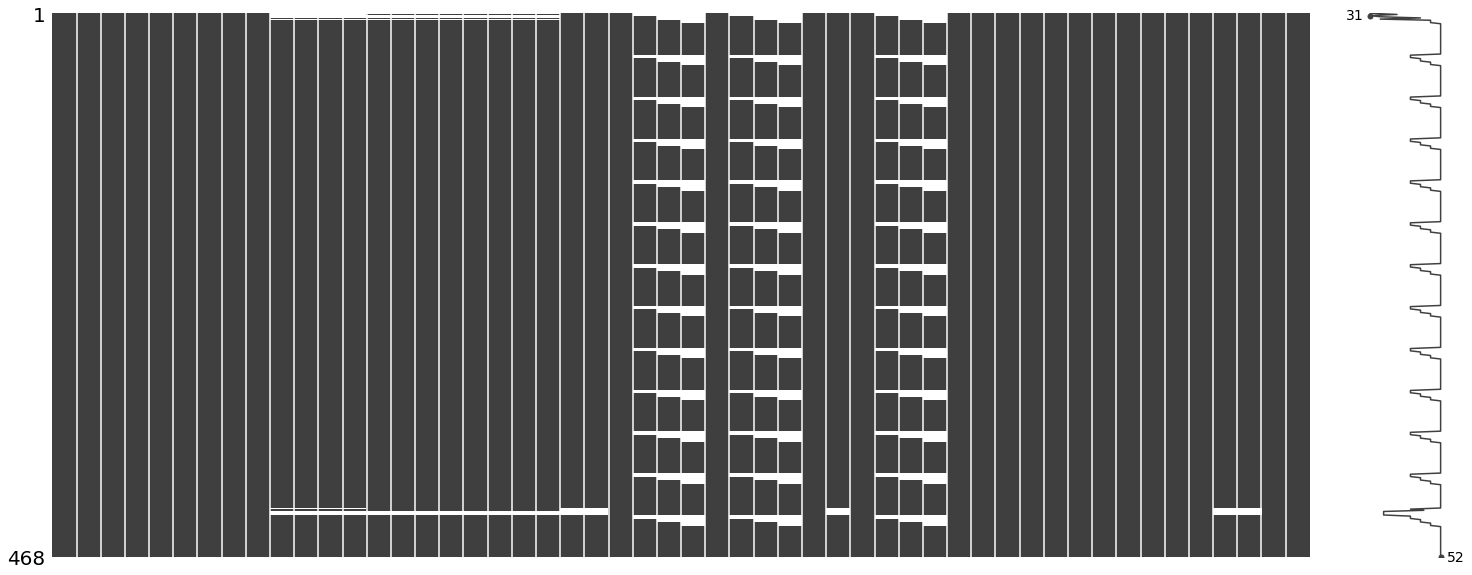

In [59]:
missingno.matrix(merged)

In [60]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
5,x,0.000000
6,y,0.000000
7,month,0.000000
8,year,0.000000
9,ndvi,2.136800


In [61]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

In [62]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
5,x,0.000000
6,y,0.000000
7,month,0.000000
8,year,0.000000
9,ndvi,2.136800


In [63]:
years = merged.year.unique()
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022])

In [64]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['καρδιτσα, τρικαλα', 'λαρισα', 'μαγνησια, σποραδες'], dtype=object)

In [65]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [66]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"καρδιτσα, τρικαλα",2010,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000
1,λαρισα,2010,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000
2,"μαγνησια, σποραδες",2010,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000
3,"καρδιτσα, τρικαλα",2011,13.958333,19.250000,49.358974,841.929152,35.000000,-4.000000,39.000000,3.833333,24.333333,24.333333,3.833333,1223.000000,212.000000,2.000000,63.539911,472.000000,91.000000,91.000000,472.000000
4,λαρισα,2011,15.916667,22.500000,48.913043,906.249347,42.000000,-4.000000,46.000000,10.166667,27.333333,27.333333,5.666667,928.000000,123.000000,4.000000,50.136650,314.000000,136.000000,136.000000,284.000000
5,"μαγνησια, σποραδες",2011,15.583333,18.666667,47.863248,831.163843,37.000000,-2.000000,39.000000,7.166667,26.000000,26.000000,6.166667,1083.000000,180.000000,1.000000,59.487453,449.000000,124.000000,124.000000,381.000000
6,"καρδιτσα, τρικαλα",2012,15.458333,20.750000,43.229167,940.130149,40.000000,-8.000000,48.000000,11.333333,26.333333,26.333333,3.333333,1786.000000,341.000000,9.000000,69.864508,797.000000,51.000000,51.000000,677.000000
7,λαρισα,2012,17.750000,24.000000,46.153846,944.722181,45.000000,-7.000000,52.000000,13.666667,28.833333,28.833333,5.666667,1276.000000,185.000000,7.000000,65.541262,502.000000,54.000000,54.000000,422.000000
8,"μαγνησια, σποραδες",2012,17.291667,20.416667,44.384058,892.763415,41.000000,-5.000000,46.000000,6.000000,28.000000,28.000000,6.000000,1254.000000,206.000000,1.000000,68.589663,485.000000,30.000000,30.000000,485.000000
9,"καρδιτσα, τρικαλα",2013,15.666667,19.000000,44.186047,888.648958,38.000000,-5.000000,43.000000,5.666667,25.666667,25.666667,4.000000,1633.000000,297.000000,5.000000,74.105304,732.000000,126.000000,126.000000,724.000000


In [67]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [68]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'ημαθια')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19


In [69]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [70]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [71]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [72]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [73]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

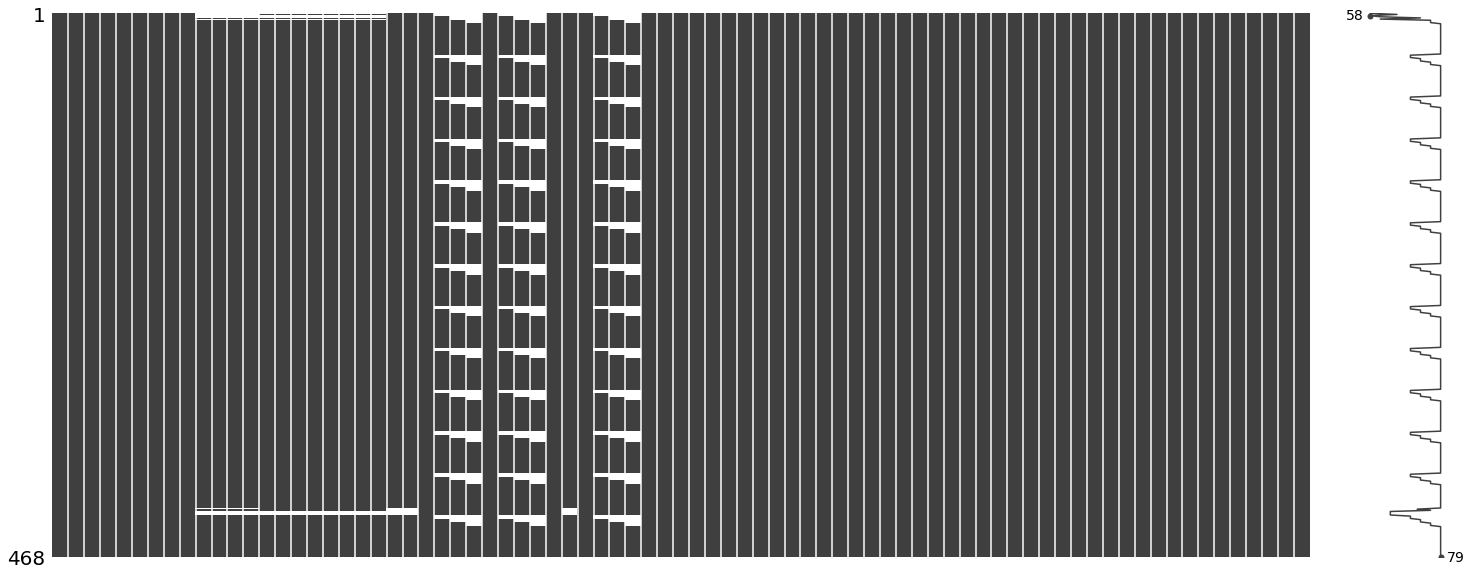

In [74]:
missingno.matrix(dataset)

In [75]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [76]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [77]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [78]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [79]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

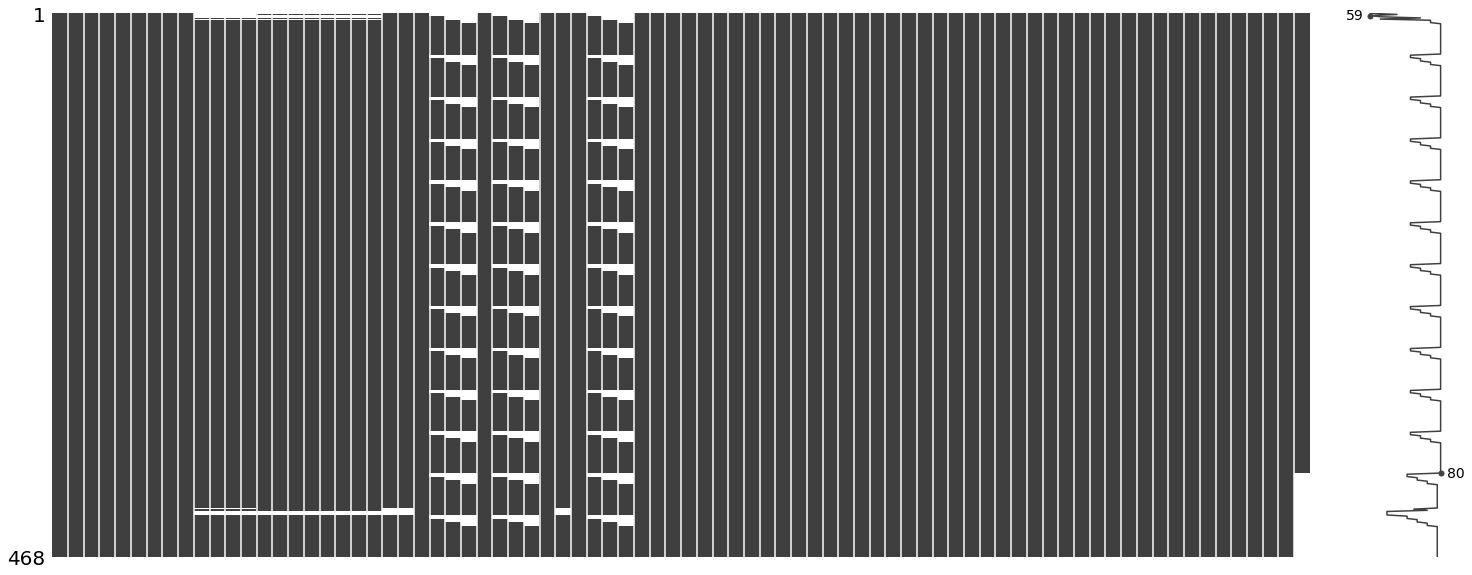

In [80]:
missingno.matrix(dataset)

In [81]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [82]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [83]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [84]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [85]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

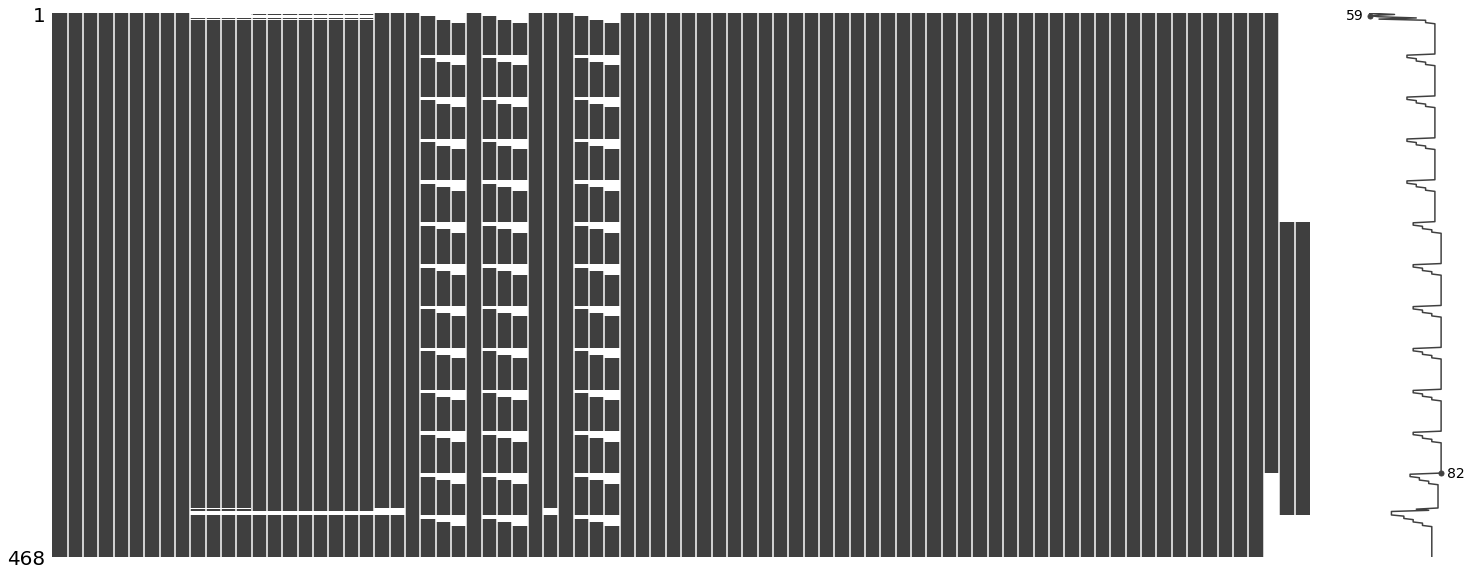

In [86]:
missingno.matrix(dataset)

In [87]:
missing = describe_dataframe(dataset)

In [88]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
5,x,0.000000
6,y,0.000000
7,month,0.000000
8,year,0.000000
9,ndvi,2.136800


In [89]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.195364,1.570202,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,3.882783,5.289864,NaN,NaN,NaN,41.517169,73.296771,117.810760,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,98.865052,-0.969514,15.761316,207.415431,0,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.047620,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,68.808664,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.674636,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,31.010417,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.839973,1.268766,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,4.554370,3.211945,2.916904,NaN,NaN,79.217105,151.965634,370.323392,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,445.038062,-3.042901,13.286678,310.442081,0,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
4,2010-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2,2010,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,11.048597,2.689361,10.127192,9.095389,NaN,NaN,1.875504,0.537745,NaN,NaN,7.380415,6.868979,6.001348,4.861217,NaN,NaN,51.045338,97.899665,193.962831,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,285.415162,-2.894380,15.076065,206.651624,0,17.291667

In [90]:
dataset.reset_index(inplace=True, drop=True)

In [91]:
dataset['cases'].value_counts()

0     439
1       6
2       5
3       4
4       3
5       2
8       2
7       2
6       2
15      1
19      1
23      1
Name: cases, dtype: int64

In [92]:
dataset['cases'].sum()

149

In [93]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.195364,1.570202,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,3.882783,5.289864,NaN,NaN,NaN,41.517169,73.296771,117.810760,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,98.865052,-0.969514,15.761316,207.415431,0,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.047620,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,68.808664,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.674636,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,31.010417,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.839973,1.268766,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,4.554370,3.211945,2.916904,NaN,NaN,79.217105,151.965634,370.323392,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,445.038062,-3.042901,13.286678,310.442081,0,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
4,2010-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2,2010,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,11.048597,2.689361,10.127192,9.095389,NaN,NaN,1.875504,0.537745,NaN,NaN,7.380415,6.868979,6.001348,4.861217,NaN,NaN,51.045338,97.899665,193.962831,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,285.415162,-2.894380,15.076065,206.651624,0,17.291667

In [94]:
dataset.drop(columns = ['week','day_sin','day_cos','month_sin','month_cos','week_sin','week_cos'], inplace = True)

In [95]:
cols = dataset.columns

In [96]:
cols

Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'lst', 'lst_jan_mean', 'lst_feb_mean',
       'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'mosq_pred',
       'monthly_lst_min', 'monthly_lst_max', 'monthly_acc_prec', 'cases',
       'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9',
       'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17',
       'bio18', 'bio19', 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
       'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 

In [97]:
len(cols)

75

In [98]:
# check columns

In [99]:
final_columns = ['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME',
                 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
                 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std',
                 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8',
                 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
                 'bio17', 'bio18', 'bio19', 
                 'lst', 'lst_day', 'lst_night', 'monthly_lst_min', 'monthly_lst_max',
                 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
                 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 
                 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 
                 'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
                 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 
                 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL','mosq_pred', 'cases']

In [100]:
len(final_columns)

75

In [101]:
dataset_final = dataset[final_columns].copy()

In [102]:
dataset_final

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,21.719540,39.504234,1,2010,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,3.882783,6.195364,1.570202,-0.969514,15.761316,5.289864,NaN,NaN,NaN,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,207.415431,41.517169,73.296771,117.810760,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,98.865052,0
1,22.405497,39.703383,1,2010,2010-01,EL61,θεσσαλια,EL612,λαρισα,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,6.047620,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN,68.808664,0
2,22.869212,39.281871,1,2010,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,6.674636,10.030960,3.318312,0.040625,16.806170,8.682121,NaN,NaN,NaN,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,150.488717,29.967839,47.912827,55.731474,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN,31.010417,0
3,21.719540,39.504234,2,2010,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,4.554370,7.839973,1.268766,-3.042901,13.286678,3.211945,2.916904,NaN,NaN,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,310.442081,79.217105,151.965634,370.323392,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,445.038062,0
4,22.405497,39.703383,2,2010,2010-02,EL61,θεσσαλια,EL612,λαρισα,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,6.868979,11.048597,2.689361,-2.894380,15.076065,6.001348,4.861217,NaN,NaN,10.127192,9.095389,NaN,NaN,1.875504,0.537745,NaN,NaN,7.380415,206.651624,51.045338,97.899665,193.962831,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN,285.415162,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

<AxesSubplot:>

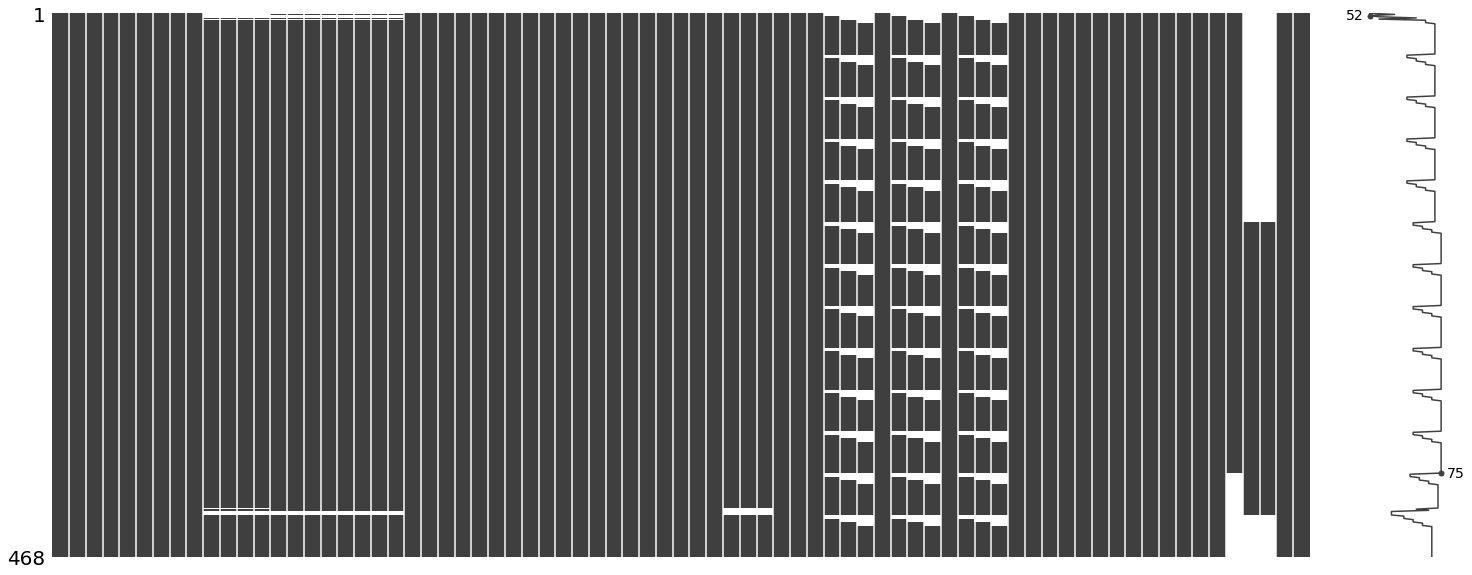

In [103]:
missingno.matrix(dataset_final)

In [104]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)